# Notebook 03: Wildfire Clustering Around Lake Tahoe

**Obstacle-Aware Clustering for Geographic Data**

This notebook applies the obstacle-aware k-Means algorithm to real-world wildfire occurrence data around Lake Tahoe. The analysis is organized into two tiers to isolate what each component adds:

- **Tier 1 (Spatial Only)**: Compares standard k-Means against the obstacle-aware algorithm using only geographic and arc-length features. This isolates the effect of the arc-length parameter $s$ without attributes mixed in.

- **Tier 2 (Spatial + Attributes)**: Adds fire size and cause type to the feature vector, using the full distance metric. This demonstrates the complete framework on real data.

### The Weighted Distance Metric

The obstacle-aware k-Means algorithm uses a composite distance that combines three domains. Between any two feature vectors $\mathbf{x}$ and $\mathbf{x}'$:

$$d^2(\mathbf{x}, \mathbf{x}') = \alpha^2 \cdot \|\text{geo} - \text{geo}'\|^2 + \beta^2 \cdot d_s(s, s')^2 + \gamma^2 \cdot \|\text{attr} - \text{attr}'\|^2$$

where:
- $\alpha$ controls the weight on **geographic** distance (Euclidean in scaled $x, y$)
- $\beta$ controls the weight on **arc-length** distance (loop-aware distance in $s$, the normalized position along the lake boundary)
- $\gamma$ controls the weight on **attribute** distance (Euclidean in fire size and cause type)

By tuning these weights, the algorithm can trade off among spatial proximity, obstacle-aware connectivity, and behavioral similarity.

### The Objective Function

To find the best weights, we minimize a composite objective using simulated annealing:

$$J = \bar{\rho} + (1 - \sigma_a)$$

where $\bar{\rho}$ is the mean within-cluster distortion (lower = tighter clusters) and $\sigma_a \in [0,1]$ is the fraction of statistically significant pairwise attribute differences between clusters (higher = more distinct clusters). In Tier 1 where there are no attributes, $\sigma_a = 0$ and $J$ simplifies to $\bar{\rho}$.

---

## 1. Setup

In [27]:
import os
# Prevent sklearn/KMeans from spawning parallel threads on Windows
# (also suppresses a harmless OpenMP warning)
os.environ['OMP_NUM_THREADS'] = '1'

# Suppress scipy.integrate accuracy warnings that surface during
# arc-length calculations on the spline boundary
import warnings
from scipy.integrate import IntegrationWarning
warnings.filterwarnings('ignore', category=IntegrationWarning)

#Standard packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Database access for the FPA FOD wildfire data
import sqlite3

# Caching utilities so expensive cells only run once
import json as json_lib
import pickle
from pathlib import Path

# sklearn baselines and preprocessing
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Optimization tools
from scipy.optimize import dual_annealing

# Our custom package
from obstacle_clustering import (
    SplineBoundary, ObstacleKMeans,
    loop_aware_distance,
    optimize_weights, attribute_separation,
)
from obstacle_clustering.optimization import objective_function

# --- Plot style ---
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 13,           # base size — affects everything
    'axes.titlesize': 15,      # subplot titles
    'axes.labelsize': 13,      # x and y axis labels
    'xtick.labelsize': 11,     # x tick numbers
    'ytick.labelsize': 11,     # y tick numbers
    'legend.fontsize': 11,
    'figure.titlesize': 16,    # suptitle
})

# Consistent cluster colors across all plots in this notebook
CLUSTER_COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# --- Caching ---
# Expensive cells (simulated annealing, objective surfaces) save their
# results so reruns are instant. Delete a file in cache_dir to force a rerun.
cache_dir = Path('../data/cached')
cache_dir.mkdir(parents=True, exist_ok=True)


def cached_or_run(cache_path, compute_fn, force_rerun=False):
    """Load from cache if it exists, otherwise run compute_fn and save."""
    cache_path = Path(cache_path)
    if cache_path.exists() and not force_rerun:
        print(f'Loading cached: {cache_path.name}')
        with open(cache_path, 'rb') as f:
            return pickle.load(f)
    print(f'Computing (will cache to {cache_path.name})...')
    result = compute_fn()
    with open(cache_path, 'wb') as f:
        pickle.dump(result, f)
    return result

## 2. Loading the Lake Tahoe Boundary

We load the cleaned boundary coordinates saved in Notebook 02 and fit the `SplineBoundary` for arc-length computation.

In [2]:
# Load boundary from Notebook 02
boundary_df = pd.read_csv('../data/boundaries/lake_tahoe_boundary.csv')
lon_boundary = boundary_df['longitude'].values
lat_boundary = boundary_df['latitude'].values

# Fit cubic splines to the cleaned boundary coordinates from Notebook 02
boundary = SplineBoundary(x_coords=lon_boundary, y_coords=lat_boundary)

L = boundary.total_arc_length()
print(f'Lake Tahoe boundary: {len(lon_boundary)} vertices')
print(f'Total arc length: {L:.4f} degrees')

# Sample for plotting (reused throughout the notebook)
spline_pts = boundary.sample_boundary(n_points=500)

Lake Tahoe boundary: 269 vertices
Total arc length: 1.2027 degrees


## 3. Loading Wildfire Data

The [Fire Program Analysis Fire-Occurrence Database (FPA FOD)](https://www.fs.usda.gov/rds/archive/catalog/RDS-2013-0009.6) is a national database of wildfires reported in the United States from 1992 to 2020. We query the SQLite database for fires within a bounding box around Lake Tahoe (roughly 38.85°–39.35° N, 120.25°–119.85° W), which captures fires on the shoreline and in the surrounding basin.

**Important**: The FPA FOD SQLite file is not included in this repository due to its size (~2 GB). To reproduce this analysis:
1. Download `FPA_FOD_20221014.sqlite` from the [USFS Research Data Archive](https://www.fs.usda.gov/rds/archive/catalog/RDS-2013-0009.6)
2. Rename to `fires.sqlite` and place in the `data/raw/` directory

In [3]:
# Connect to the FPA FOD SQLite database
db_path = '../data/raw/fires.sqlite'  

# Query fires in the Lake Tahoe area
query = """
    SELECT LATITUDE, LONGITUDE, FIRE_SIZE, NWCG_GENERAL_CAUSE,
           NWCG_CAUSE_CLASSIFICATION, FIRE_YEAR, DISCOVERY_DOY
    FROM Fires
    WHERE LATITUDE BETWEEN 38.85 AND 39.35
      AND LONGITUDE BETWEEN -120.25 AND -119.85
"""

with sqlite3.connect(db_path) as conn:
    fires_raw = pd.read_sql_query(query, conn)

print(f'Total fires in Lake Tahoe area: {len(fires_raw)}')
print(f'Year range: {fires_raw["FIRE_YEAR"].min()} - {fires_raw["FIRE_YEAR"].max()}')
print(f'\nCause breakdown:')
print(fires_raw['NWCG_GENERAL_CAUSE'].value_counts().to_string())

Total fires in Lake Tahoe area: 1888
Year range: 1992 - 2020

Cause breakdown:
NWCG_GENERAL_CAUSE
Recreation and ceremony                       500
Missing data/not specified/undetermined       423
Natural                                       374
Smoking                                       181
Arson/incendiarism                             97
Misuse of fire by a minor                      87
Debris and open burning                        86
Equipment and vehicle use                      78
Power generation/transmission/distribution     44
Fireworks                                      11
Other causes                                    6
Railroad operations and maintenance             1


## 4. Data Cleaning and Feature Engineering

We prepare the data for clustering in four steps:

1. **Filter out "Missing data/not specified/undetermined" cause entries** -- without a known cause, these fires can't be encoded as natural vs. human
2. **Encode cause as binary**: Natural (lightning) vs. Human (all other known causes)
3. **Project each fire onto the lake boundary** to calculate its arc-length parameter $s$
4. **Normalize the geographic coordinates and fire size** to put them on comparable scales with $s$ 

In [5]:
# --- Step 1: Filter out missing cause data ---
fires = fires_raw[
    fires_raw['NWCG_GENERAL_CAUSE'] != 'Missing data/not specified/undetermined'
].copy()
print(f'Fires after filtering missing cause: {len(fires)}')

# --- Step 2: Encode cause as binary ---
# Encode NWCG cause as binary: 0 = Natural, 1 = Human-caused
fires['cause_binary'] = (fires['NWCG_GENERAL_CAUSE'] != 'Natural').astype(int)

print(f'\nCause classification:')
print(f"  Natural (lightning): {(fires['cause_binary'] == 0).sum()}")
print(f"  Human-caused:        {(fires['cause_binary'] == 1).sum()}")

print(f'\nFire size (acres):')
print(f"  Min:    {fires['FIRE_SIZE'].min():.4f}")
print(f"  Median: {fires['FIRE_SIZE'].median():.2f}")
print(f"  Mean:   {fires['FIRE_SIZE'].mean():.2f}")
print(f"  Max:    {fires['FIRE_SIZE'].max():.2f}")

Fires after filtering missing cause: 1465

Cause classification:
  Natural (lightning): 374
  Human-caused:        1091

Fire size (acres):
  Min:    0.0100
  Median: 0.10
  Mean:   9.38
  Max:    4222.00


In [6]:
# --- Step 3: Project each fire onto the lake boundary ---
# This may take several minutes on first run; subsequent runs load from cache.
# NOTE: If you change the fire bounding box (Cell 6) or re-clean the
# boundary (Notebook 02), delete data/cached/fire_projections.pkl to
# force a recompute.

def project_all_fires():
    print('Projecting fire locations onto lake boundary...')
    lons = fires['LONGITUDE'].values
    lats = fires['LATITUDE'].values
    n = len(fires)

    t_arr = np.zeros(n)
    s_arr = np.zeros(n)
    for idx in range(n):
        if idx % 200 == 0:
            print(f'  {idx}/{n} ({100*idx/n:.0f}%)')
        t_arr[idx], s_arr[idx] = boundary.project_point(lons[idx], lats[idx])
    return t_arr, s_arr


t_values, s_values = cached_or_run(
    cache_dir / 'fire_projections.pkl',
    project_all_fires,
)

fires['t_param'] = t_values
fires['s_param'] = s_values

print(f'Projection complete: {len(fires)} fires projected')
print(f's range: [{fires["s_param"].min():.4f}, {fires["s_param"].max():.4f}]')

Computing (will cache to fire_projections.pkl)...
Projecting fire locations onto lake boundary...
  0/1465 (0%)
  200/1465 (14%)
  400/1465 (27%)
  600/1465 (41%)
  800/1465 (55%)
  1000/1465 (68%)
  1200/1465 (82%)
  1400/1465 (96%)
Projection complete: 1465 fires projected
s range: [0.0069, 0.9980]


### Fire Size Distribution

Fire sizes in the FPA FOD span many orders of magnitude (from tiny spot fires to thousands of acres). We compare the raw distribution to a log-transformed version to motivate using the log scale in clustering.

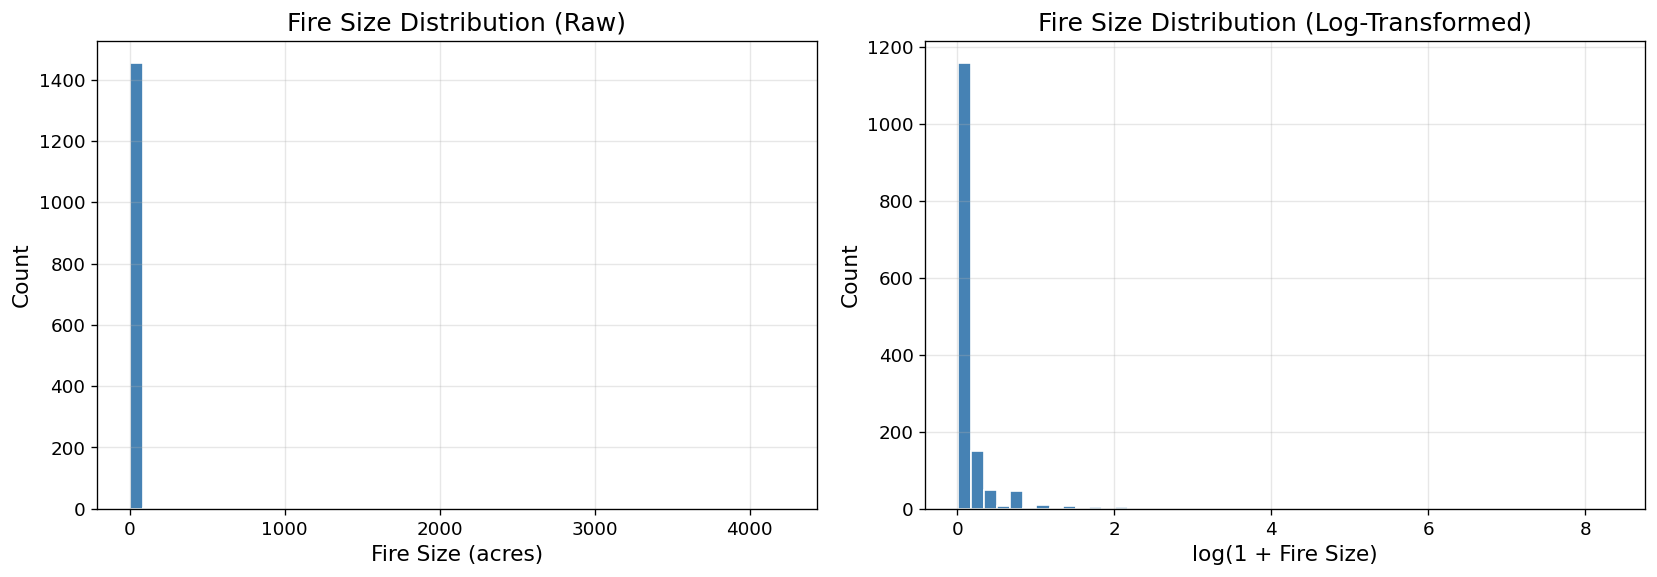

In [9]:
# Compare raw vs. log-transformed fire size distributions
# log1p = log(1+x) handles fires recorded with size 0 cleanly
fires['fire_size_log'] = np.log1p(fires['FIRE_SIZE'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
ax = axes[0]
ax.hist(fires['FIRE_SIZE'], bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('Fire Size (acres)')
ax.set_ylabel('Count')
ax.set_title('Fire Size Distribution (Raw)')
ax.grid(True, alpha=0.3)

# Log-transformed
ax = axes[1]
ax.hist(fires['fire_size_log'], bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('log(1 + Fire Size)')
ax.set_ylabel('Count')
ax.set_title('Fire Size Distribution (Log-Transformed)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# --- Step 4: Normalize features ---
# Geographic coordinates: Min-Max scale to [0, 1]
scaler_xy = MinMaxScaler()
xy_scaled = scaler_xy.fit_transform(fires[['LONGITUDE', 'LATITUDE']].values)

# Fire size (log): Min-Max scale to [0, 1]
scaler_size = MinMaxScaler()
fire_size_scaled = scaler_size.fit_transform(fires[['fire_size_log']].values)

# s is already in [0, 1]
# cause_binary is already 0 or 1

# Assemble feature matrix: [x_scaled, y_scaled, s, fire_size_scaled, cause_binary]
X = np.column_stack([
    xy_scaled,                          # columns 0, 1: geographic
    fires['s_param'].values,            # column 2: arc-length
    fire_size_scaled.ravel(),           # column 3: fire size (log + normalized)
    fires['cause_binary'].values        # column 4: cause type
])

# Feature names in order -- used downstream for plot labels and attribute indexing
feature_names = ['x_scaled', 'y_scaled', 's', 'fire_size', 'cause_type']

# This full feature matrix gets used in Tier 2.
# Tier 1 will use only X[:, :3] (geography + arc-length, no attributes)

print(f'Feature matrix shape: {X.shape}')
print(f'Features: {feature_names}')
print(f'\nFirst 5 rows:')
print(np.array2string(X[:5], precision=4, suppress_small=True))

Feature matrix shape: (1465, 5)
Features: ['x_scaled', 'y_scaled', 's', 'fire_size', 'cause_type']

First 5 rows:
[[0.9395 0.4711 0.6338 0.0474 0.    ]
 [0.9687 0.3394 0.6989 0.0102 0.    ]
 [0.9514 0.3917 0.6663 0.0102 0.    ]
 [0.1661 0.3167 0.026  0.0102 1.    ]
 [0.4955 0.1822 0.8678 0.0102 1.    ]]


In [ ]:
# Save processed fire data as a CSV 
processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

processed_path = processed_dir / 'tahoe_fires_processed.csv'
fires.to_csv(processed_path, index=False)

print(f'Saved {len(fires)} fires to {processed_path}')
print('Columns: LONGITUDE, LATITUDE, FIRE_SIZE, NWCG_GENERAL_CAUSE,')
print('         FIRE_YEAR, DISCOVERY_DOY, cause_binary, t_param, s_param, fire_size_log')

Saved 1465 fires to ..\data\processed\tahoe_fires_processed.csv
Columns: LONGITUDE, LATITUDE, FIRE_SIZE, NWCG_GENERAL_CAUSE,
         FIRE_YEAR, DISCOVERY_DOY, cause_binary, t_param, s_param, fire_size_log


## 5. Visualizing the Raw Data

Before clustering, we look at the spatial distribution of fires around the lake. The left panel colors each fire by cause (natural vs. human), and the right panel colors by arc-length position $s$ around the perimeter.

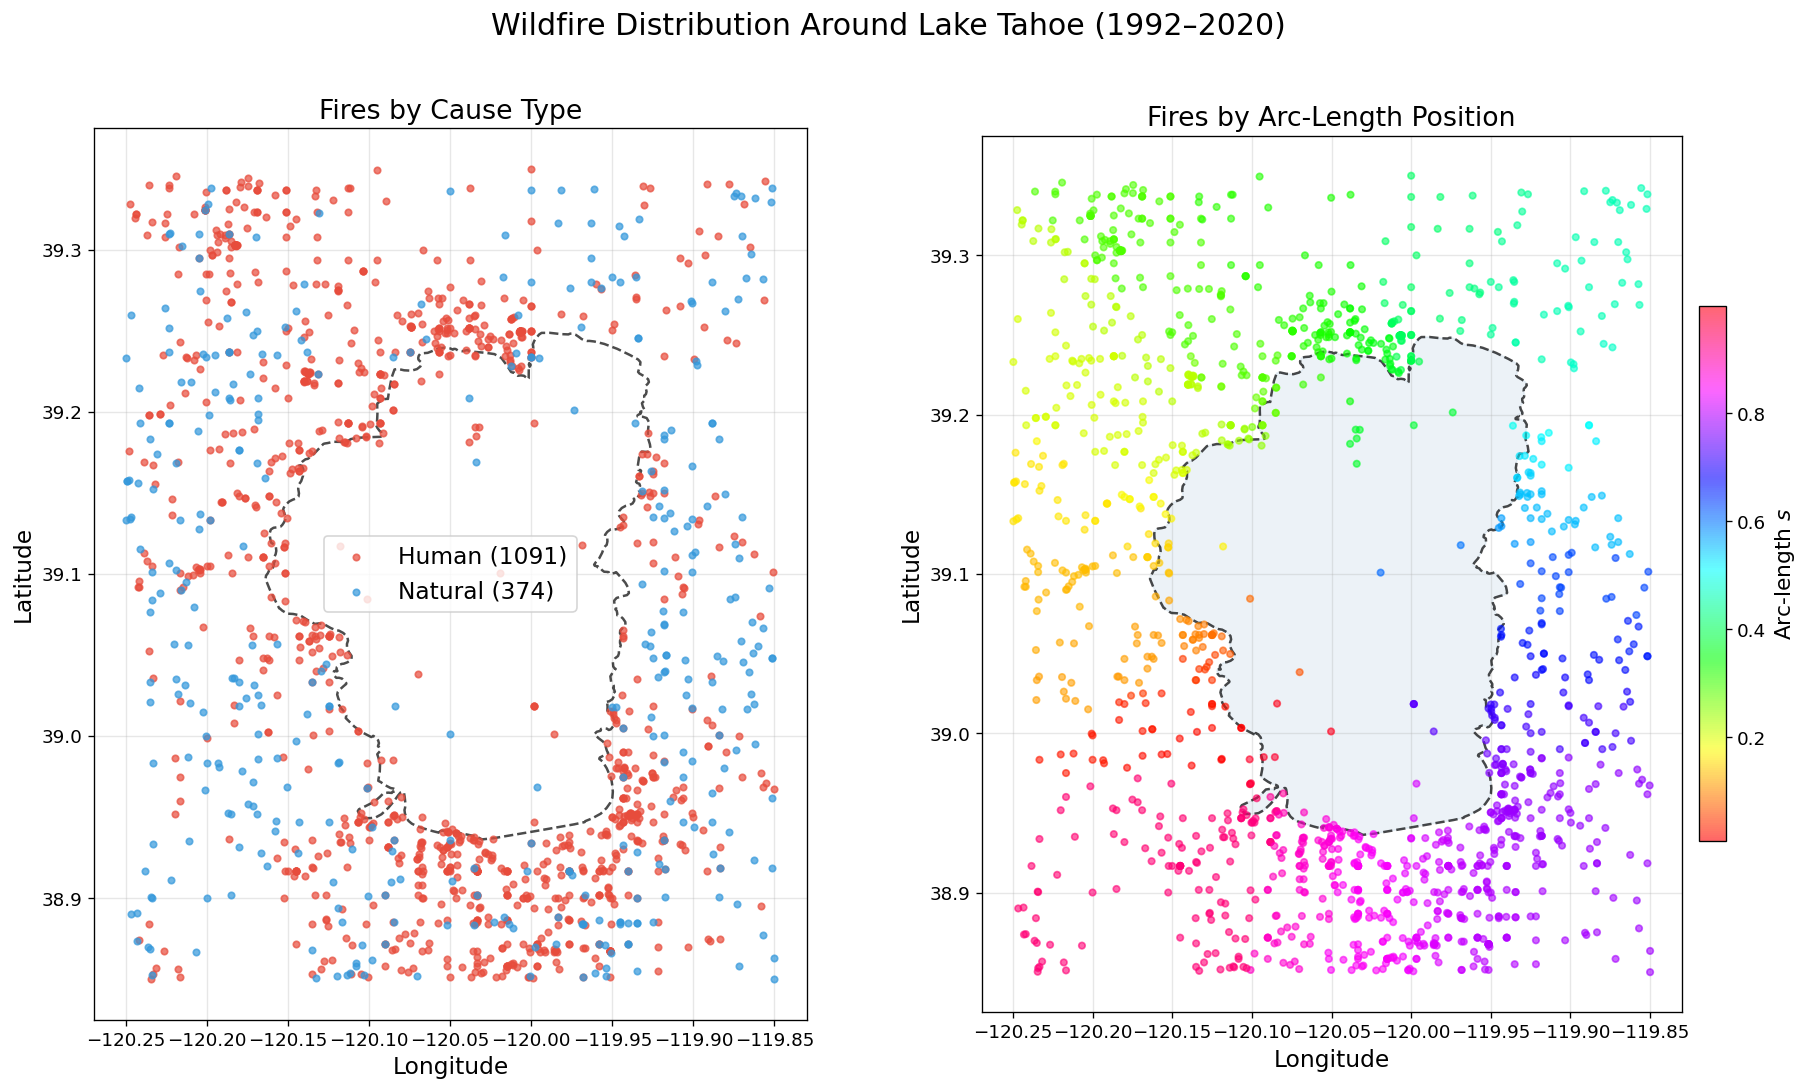

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# --- Left panel: by cause ---
ax = axes[0]
ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0., color='steelblue')

natural = fires[fires['cause_binary'] == 0]
human = fires[fires['cause_binary'] == 1]

# Plot human first, natural on top 
ax.scatter(human['LONGITUDE'], human['LATITUDE'],
           c='#e74c3c', s=15, alpha=0.7, label=f'Human ({len(human)})', zorder=3)
ax.scatter(natural['LONGITUDE'], natural['LATITUDE'],
           c='#3498db', s=15, alpha=0.7, label=f'Natural ({len(natural)})', zorder=3)

ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)
ax.set_title('Fires by Cause Type', fontsize=16)
ax.legend(fontsize=14)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# --- Right panel: by arc-length position ---
# HSV colormap wraps around so s=0 and s=1 show the same color
ax = axes[1]
ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

scatter = ax.scatter(fires['LONGITUDE'], fires['LATITUDE'],
                     c=fires['s_param'], cmap='hsv', s=15, alpha=0.6, zorder=3)
plt.colorbar(scatter, ax=ax, label='Arc-length $s$', shrink=0.6, aspect=20, pad=0.02)

ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)
ax.set_title('Fires by Arc-Length Position', fontsize=16)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

year_min = fires['FIRE_YEAR'].min()
year_max = fires['FIRE_YEAR'].max()
plt.suptitle(f'Wildfire Distribution Around Lake Tahoe ({year_min}–{year_max})',
             fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

---

# TIER 1: Spatial-Only Comparison

**Goal**: Isolate the effect of the arc-length parameter $s$ on clustering quality, without attributes.

In Tier 1, all methods use $\gamma = 0$ (no attribute component). The distance metric simplifies to:

$$d^2(\mathbf{x}, \mathbf{x}') = \alpha^2 \cdot \|\text{geo} - \text{geo}'\|^2 + \beta^2 \cdot d_s(s, s')^2$$

We compare three approaches:
1. **Standard k-Means** on $(x, y)$ -- baseline, ignoring the obstacle
2. **Obstacle-aware k-Means** on $(x, y, s)$ with $\alpha = 1, \beta = 1$ -- equal spatial weights
3. **Obstacle-aware k-Means** on $(x, y, s)$ with $\alpha = 1$, optimized $\beta$ -- tuned with simulated annealing

## 6. Spatial-Only Feature Matrix

For Tier 1 we slice off the first three columns of the full feature matrix to build a spatial-only matrix `X_spatial`. The same matrix gets used in both the baseline standard k-Means and the obstacle-aware k-Means in this tier.

In [30]:
# Tier 1 uses only the spatial features (no attributes)
X_spatial = X[:, :3]

print(f'Tier 1 feature matrix shape: {X_spatial.shape}')
print(f'Features: {feature_names[:3]}')

Tier 1 feature matrix shape: (1465, 3)
Features: ['x_scaled', 'y_scaled', 's']


## 7. Choosing the Number of Clusters (elbow method)

Before running any clustering, we use the elbow method to choose $k$. The method runs k-Means for a range of $k$ values and plots the inertia (within-cluster sum of squared distances) for each. A good $k$ is where the curve bends; adding more clusters beyond that point gives diminishing returns.

We use standard k-Means here since the elbow method is about the data's natural cluster structure, not about the choice of distance metric.

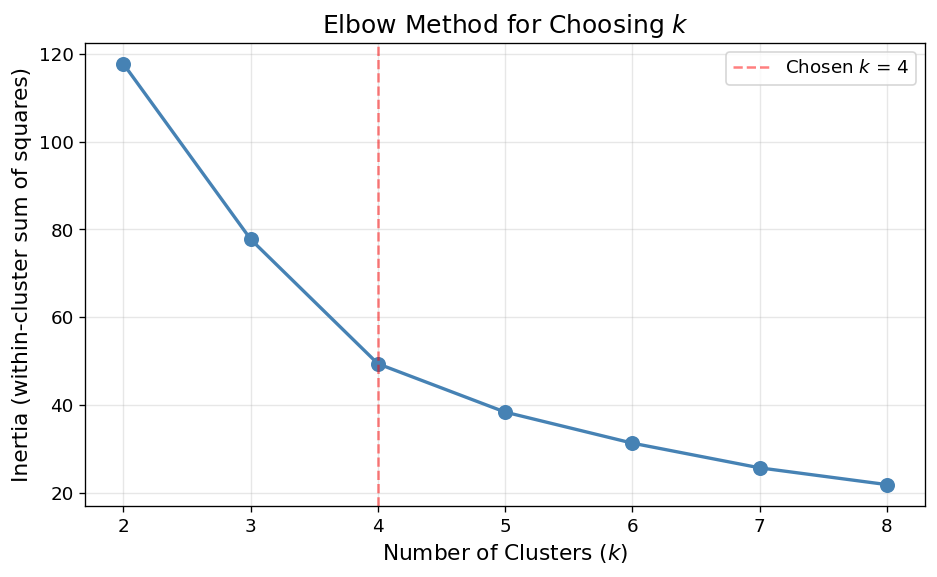

Inertia by k:
  k=2: 117.7308
  k=3: 77.7684
  k=4: 49.4114
  k=5: 38.4030
  k=6: 31.3317
  k=7: 25.7065
  k=8: 21.8872


In [31]:
# Elbow method: test k = 2 through 8
k_range = range(2, 9)
inertias = []

for k_test in k_range:
    km = KMeans(n_clusters=k_test, random_state=42, n_init=10)
    km.fit(xy_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inertias, marker='o', color='steelblue', linewidth=2, markersize=8)

# Mark the chosen k
ax.axvline(x=4, color='red', linestyle='--', alpha=0.5, label='Chosen $k$ = 4')

ax.set_xlabel('Number of Clusters ($k$)')
ax.set_ylabel('Inertia (within-cluster sum of squares)')
ax.set_title('Elbow Method for Choosing $k$')
ax.set_xticks(list(k_range))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the values for reference
print('Inertia by k:')
for k_test, inertia in zip(k_range, inertias):
    print(f'  k={k_test}: {inertia:.4f}')

The inertia curve flattens noticeably after $k = 4$, suggesting four clusters fit the spatial structure well. We use $k = 4$ throughout the rest of the notebook.

## 8. Standard k-Means Baseline

As a baseline, we run standard k-Means using only the geographic coordinates $(x, y)$. This treats the space as unobstructed and ignores fire attributes entirely. The result gives us a comparison point for the obstacle-aware version in Tier 1.

In [32]:
# Standard k-Means on (x, y) only
k = 4
kmeans_standard = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_standard = kmeans_standard.fit_predict(xy_scaled)

print(f'Standard k-Means converged in {kmeans_standard.n_iter_} iterations')
print(f'\nCluster sizes:')
for i in range(k):
    n = np.sum(labels_standard == i)
    print(f'  Cluster {i+1}: {n} fires')

Standard k-Means converged in 14 iterations

Cluster sizes:
  Cluster 1: 390 fires
  Cluster 2: 466 fires
  Cluster 3: 272 fires
  Cluster 4: 337 fires


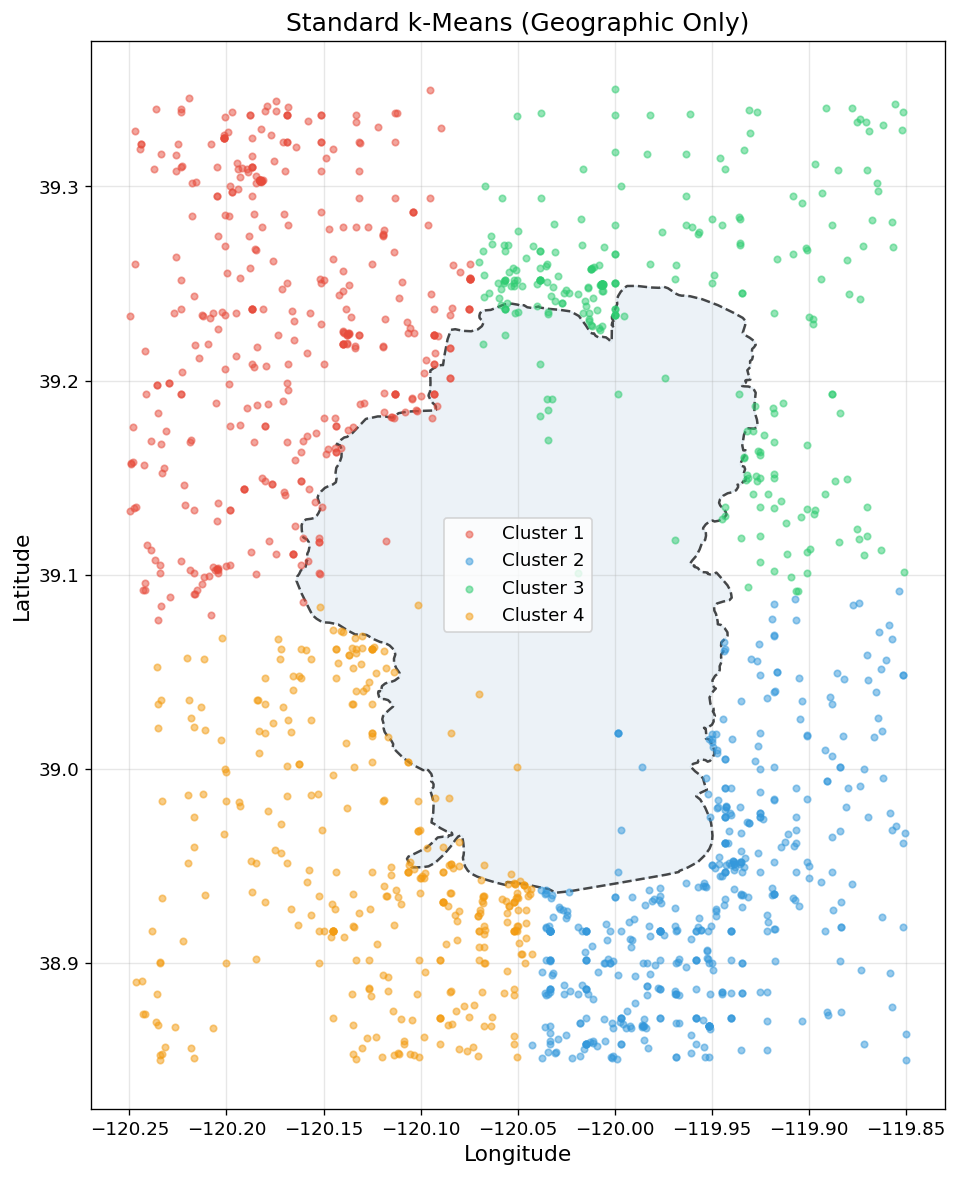

In [33]:
# Plot standard k-Means results
fig, ax = plt.subplots(figsize=(10, 10))

for i in range(k):
    mask = labels_standard == i
    ax.scatter(fires['LONGITUDE'].values[mask], fires['LATITUDE'].values[mask],
               c=CLUSTER_COLORS[i], s=15, alpha=0.5, label=f'Cluster {i+1}', zorder=3)

ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Standard k-Means (Geographic Only)')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Obstacle-Aware k-Means (Equal Weights)

We start with $\alpha = 1, \beta = 1$, which gives geographic distance and arc-length distance equal influence on cluster assignments.  The next section asks whether a different balance improves the clustering.

In [36]:
# Obstacle-aware k-Means: spatial only, equal weights (alpha = beta = 1)
model_t1_equal = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=1.0, gamma=0.0,    # no attributes
    random_state=42, n_attr=0
)
model_t1_equal.fit(X_spatial, t_data=fires['t_param'].values)
labels_t1_equal = model_t1_equal.labels_

print(f'Tier 1 equal weights: converged in {model_t1_equal.n_iter_} iterations')
print(f'rho_bar: {model_t1_equal.rho_bar_:.4f}')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_t1_equal == i)} fires')

Tier 1 equal weights: converged in 11 iterations
rho_bar: 0.0398

Cluster sizes:
  Cluster 1: 275 fires
  Cluster 2: 390 fires
  Cluster 3: 378 fires
  Cluster 4: 422 fires


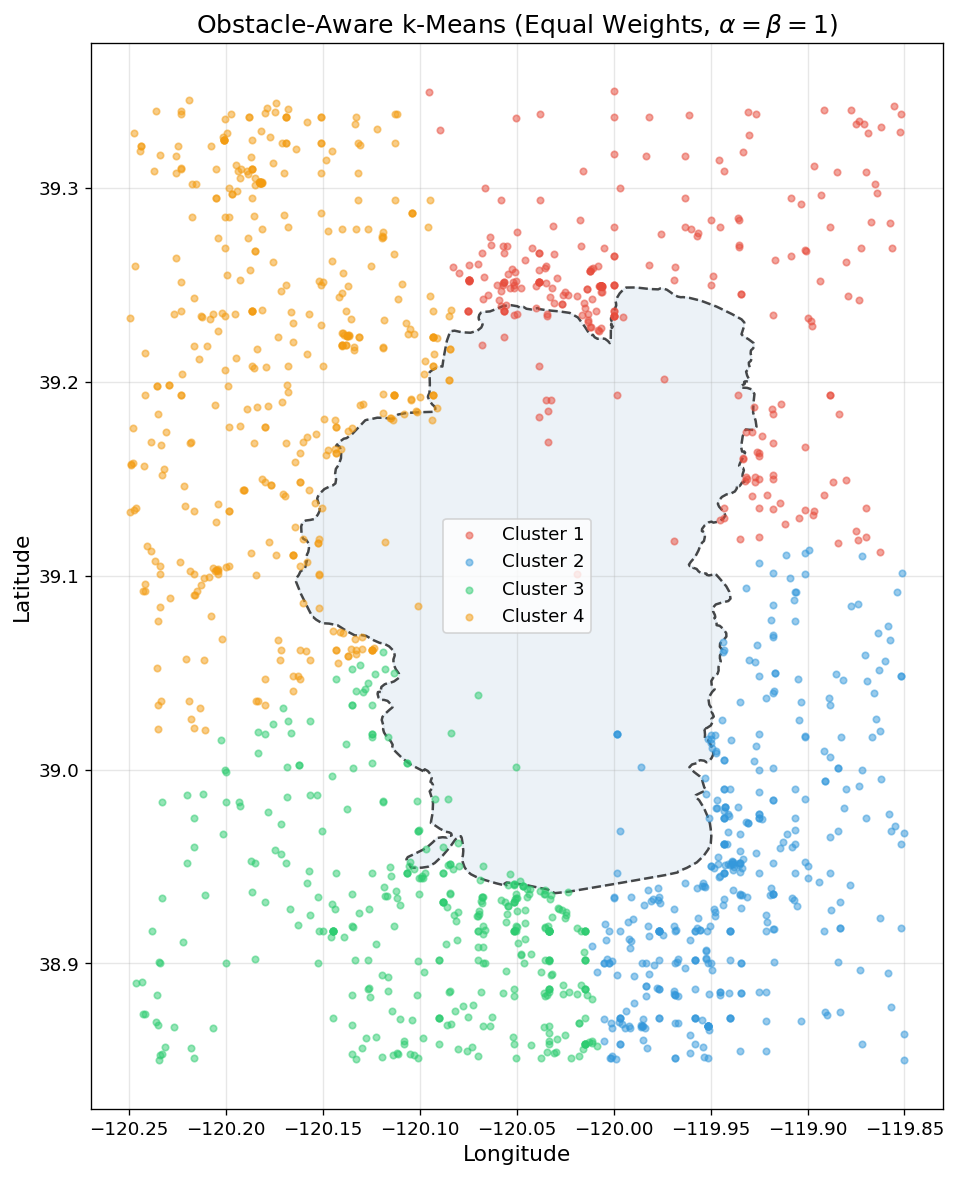

In [37]:
# Plot Tier 1 equal-weights clustering results
fig, ax = plt.subplots(figsize=(10, 10))

for i in range(k):
    mask = labels_t1_equal == i
    ax.scatter(fires['LONGITUDE'].values[mask], fires['LATITUDE'].values[mask],
               c=CLUSTER_COLORS[i], s=15, alpha=0.5, label=f'Cluster {i+1}', zorder=3)

ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(r'Obstacle-Aware k-Means (Equal Weights, $\alpha = \beta = 1$)')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Optimizing $\beta$

We fix $\alpha = 1$ since only the *ratios* between weights affect cluster assignments. 

With $\gamma = 0$ (no attributes), the optimization becomes a 1D search over $\beta \in [0, 2]$. The objective in Tier 1 is simply $J = \bar{\rho}$, the mean within-cluster distortion. We minimize how spread out each cluster is in the combined $(x, y, s)$ space.

**Note**: The first run takes approximately 15-30 minutes. The progress callback prints each time a new best solution is found. Subsequent runs load the cached result instantly.

In [ ]:
# 1D optimization: find optimal beta with alpha=1, gamma=0
alpha_fixed = 1.0

def objective_t1(params):
    """Objective for Tier 1: optimize beta only, gamma=0."""
    beta = params[0]
    return objective_function(
        (alpha_fixed, beta, 0.0),
        X_spatial, fires['t_param'].values, boundary,
        k=k, n_attr=0, attr_indices=[], random_state=42
    )

def progress_callback(x, f, context):
    print(f'  beta={x[0]:.4f}, J(=rho_bar)={f:.4f}')


def run_tier1_optimization():
    """Run simulated annealing and refit the model with the optimal beta."""
    print('Tier 1: Optimizing beta (alpha=1.0, gamma=0.0)...')
    sa_result = dual_annealing(
        objective_t1,
        bounds=[(0, 2)],
        seed=42,
        maxiter=100,
        callback=progress_callback
    )

    # Refit with optimal beta
    opt_beta = sa_result.x[0]
    model = ObstacleKMeans(
        k=k, boundary=boundary,
        alpha=alpha_fixed, beta=opt_beta, gamma=0.0,
        random_state=42, n_attr=0
    )
    model.fit(X_spatial, t_data=fires['t_param'].values)
    return sa_result, model


# Cache the optimization result and refit model together
sa_t1, model_t1_opt = cached_or_run(
    cache_dir / 'tier1_optimization.pkl',
    run_tier1_optimization,
)

opt_beta_t1 = sa_t1.x[0]
labels_t1_opt = model_t1_opt.labels_

print(f'\nOptimal beta: {opt_beta_t1:.4f}')
print(f'Objective (rho_bar): {model_t1_opt.rho_bar_:.4f}')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_t1_opt == i)} fires')

Computing (will cache to tier1_optimization.pkl)...
Tier 1: Optimizing beta (alpha=1.0, gamma=0.0)...
  beta=1.5323, J(=rho_bar)=1.0397


### Validating the Optimization

Before looking at the clustering result, we plot the objective curve to verify the optimization found a meaningful minimum. Because the Tier 1 optimization is 1D, the curve is a clean line plot of $J(\beta) = \bar{\rho}(\beta)$.

Computing Tier 1 objective curve...
  5/20
  10/20
  15/20
  20/20


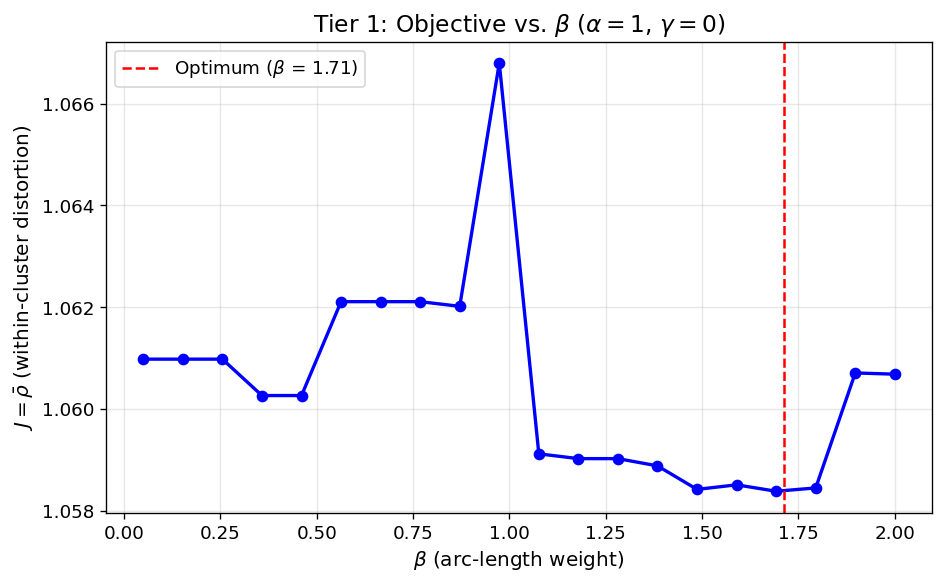

Curve computation complete.


In [ ]:
# Compute objective values across a grid of beta to plot the curve

def compute_tier1_objective_curve():
    print('Computing Tier 1 objective curve...')
    beta_grid = np.linspace(0.05, 2.0, 20)
    J_grid = np.zeros(len(beta_grid))
    for i, b in enumerate(beta_grid):
        J_grid[i] = objective_function(
            (alpha_fixed, b, 0.0),
            X_spatial, fires['t_param'].values, boundary,
            k=k, n_attr=0, attr_indices=[], random_state=42
        )
        if (i + 1) % 5 == 0:
            print(f'  {i+1}/{len(beta_grid)}')
    return beta_grid, J_grid


beta_grid_t1, J_grid_t1 = cached_or_run(
    cache_dir / 'tier1_objective_curve.pkl',
    compute_tier1_objective_curve,
)

print(f'Curve has {len(beta_grid_t1)} points; '
      f'min J = {J_grid_t1.min():.4f} at beta = {beta_grid_t1[np.argmin(J_grid_t1)]:.3f}')


# Plot the objective curve with the optimum marked
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(beta_grid_t1, J_grid_t1, marker='o', color='steelblue', linewidth=2, markersize=6)
ax.axvline(opt_beta_t1, color='red', linestyle='--', linewidth=1.5,
           label=fr'Optimum ($\beta$ = {opt_beta_t1:.2f})')

ax.set_xlabel(r'$\beta$ (arc-length weight)')
ax.set_ylabel(r'$J = \bar{\rho}$ (within-cluster distortion)')
ax.set_title(r'Tier 1 Objective Curve ($\alpha = 1$, $\gamma = 0$)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Tier 1: Quantitative Evaluation

We evaluate the three Tier 1 methods using two metrics:

**$\bar{\rho}$ (within-cluster distortion)**: Measures how tightly clustered each method's assignments are in the $(x, y, s)$ space. Note that $\bar{\rho}$ is only directly comparable between the two obstacle-aware methods (which both use the same distance metric); the standard k-Means $\bar{\rho}$ is computed differently because it doesn't include the arc-length component.

**Arc-length span**: For each cluster, the smallest arc on the boundary that contains all of that cluster's fire positions. This metric *is* directly comparable across all methods because it evaluates the cluster labels using the same calculation regardless of how the labels were produced. A lower span means the cluster's fires are more concentrated on one side of the lake — i.e., more spatially coherent around the obstacle.

In [ ]:
from obstacle_clustering import loop_aware_distance

def arc_length_span(s_values):
    """
    Compute the smallest arc on [0,1] that contains all s values.
    
    For circular data, we sort the values, find the largest gap between 
    consecutive points (including the wrap-around gap), and the span is 
    1 minus that largest gap. The largest gap is the stretch of shoreline 
    where the cluster has NO fires; everything else is where fires ARE.
    """
    if len(s_values) <= 1:
        return 0.0
    s_sorted = np.sort(s_values % 1.0)
    gaps = np.diff(s_sorted)
    wrap_gap = (1.0 - s_sorted[-1]) + s_sorted[0]
    all_gaps = np.append(gaps, wrap_gap)
    return 1.0 - np.max(all_gaps)

# Compute both metrics for all Tier 1 methods
print('TIER 1 QUANTITATIVE COMPARISON')
print('=' * 80)

# Arc-length span
methods_t1 = {
    'Standard k-Means (x, y)': labels_standard,
    'Obstacle-Aware (alpha=1, beta=1)': labels_t1_equal,
    f'Obstacle-Aware (alpha=1, beta={opt_beta_t1:.2f})': labels_t1_opt,
}

print(f'\n{"Method":<42} {"rho_bar":>10} {"Cl 1":>8} {"Cl 2":>8} {"Cl 3":>8} {"Mean":>8}')
print('-' * 80)

# Standard k-Means: compute rho_bar without s component (just x,y)
rho_std = 0.0
for i in range(k):
    members = np.where(labels_standard == i)[0]
    if len(members) > 0:
        cx = np.mean(xy_scaled[members, 0])
        cy = np.mean(xy_scaled[members, 1])
        rho_std += np.mean((xy_scaled[members, 0] - cx)**2 + 
                           (xy_scaled[members, 1] - cy)**2)
rho_std /= k

spans_std = [arc_length_span(fires['s_param'].values[labels_standard == i]) for i in range(k)]
print(f'{"Standard k-Means (x, y)":<42} {rho_std:>10.4f}* {spans_std[0]:>8.3f} {spans_std[1]:>8.3f} {spans_std[2]:>8.3f} {np.mean(spans_std):>8.3f}')

# Obstacle-aware equal
spans_eq = [arc_length_span(fires['s_param'].values[labels_t1_equal == i]) for i in range(k)]
print(f'{"Obstacle-Aware (alpha=1, beta=1)":<42} {model_t1_equal.rho_bar_:>10.4f} {spans_eq[0]:>8.3f} {spans_eq[1]:>8.3f} {spans_eq[2]:>8.3f} {np.mean(spans_eq):>8.3f}')

# Obstacle-aware optimized
spans_opt = [arc_length_span(fires['s_param'].values[labels_t1_opt == i]) for i in range(k)]
print(f'{"Obstacle-Aware (alpha=1, beta=" + f"{opt_beta_t1:.2f})":<42} {model_t1_opt.rho_bar_:>10.4f} {spans_opt[0]:>8.3f} {spans_opt[1]:>8.3f} {spans_opt[2]:>8.3f} {np.mean(spans_opt):>8.3f}')

print(f'\n* Standard k-Means rho_bar computed on (x,y) only; obstacle-aware')
print(f'  rho_bar computed on (x,y,s). These are not directly comparable.')
print(f'  Arc-length span IS directly comparable across all methods.')
print(f'  Arc span columns show per-cluster values (lower = more coherent).')

TIER 1 QUANTITATIVE COMPARISON

Method                                        rho_bar     Cl 1     Cl 2     Cl 3     Mean
--------------------------------------------------------------------------------
Standard k-Means (x, y)                        0.0524*    0.385    0.391    0.368    0.381
Obstacle-Aware (alpha=1, beta=1)               0.0668    0.364    0.344    0.279    0.329
Obstacle-Aware (alpha=1, beta=1.71)            0.0583    0.330    0.391    0.297    0.339

* Standard k-Means rho_bar computed on (x,y) only; obstacle-aware
  rho_bar computed on (x,y,s). These are not directly comparable.
  Arc-length span IS directly comparable across all methods.
  Arc span columns show per-cluster values (lower = more coherent).


## 12. Tier 1: Visual Comparison

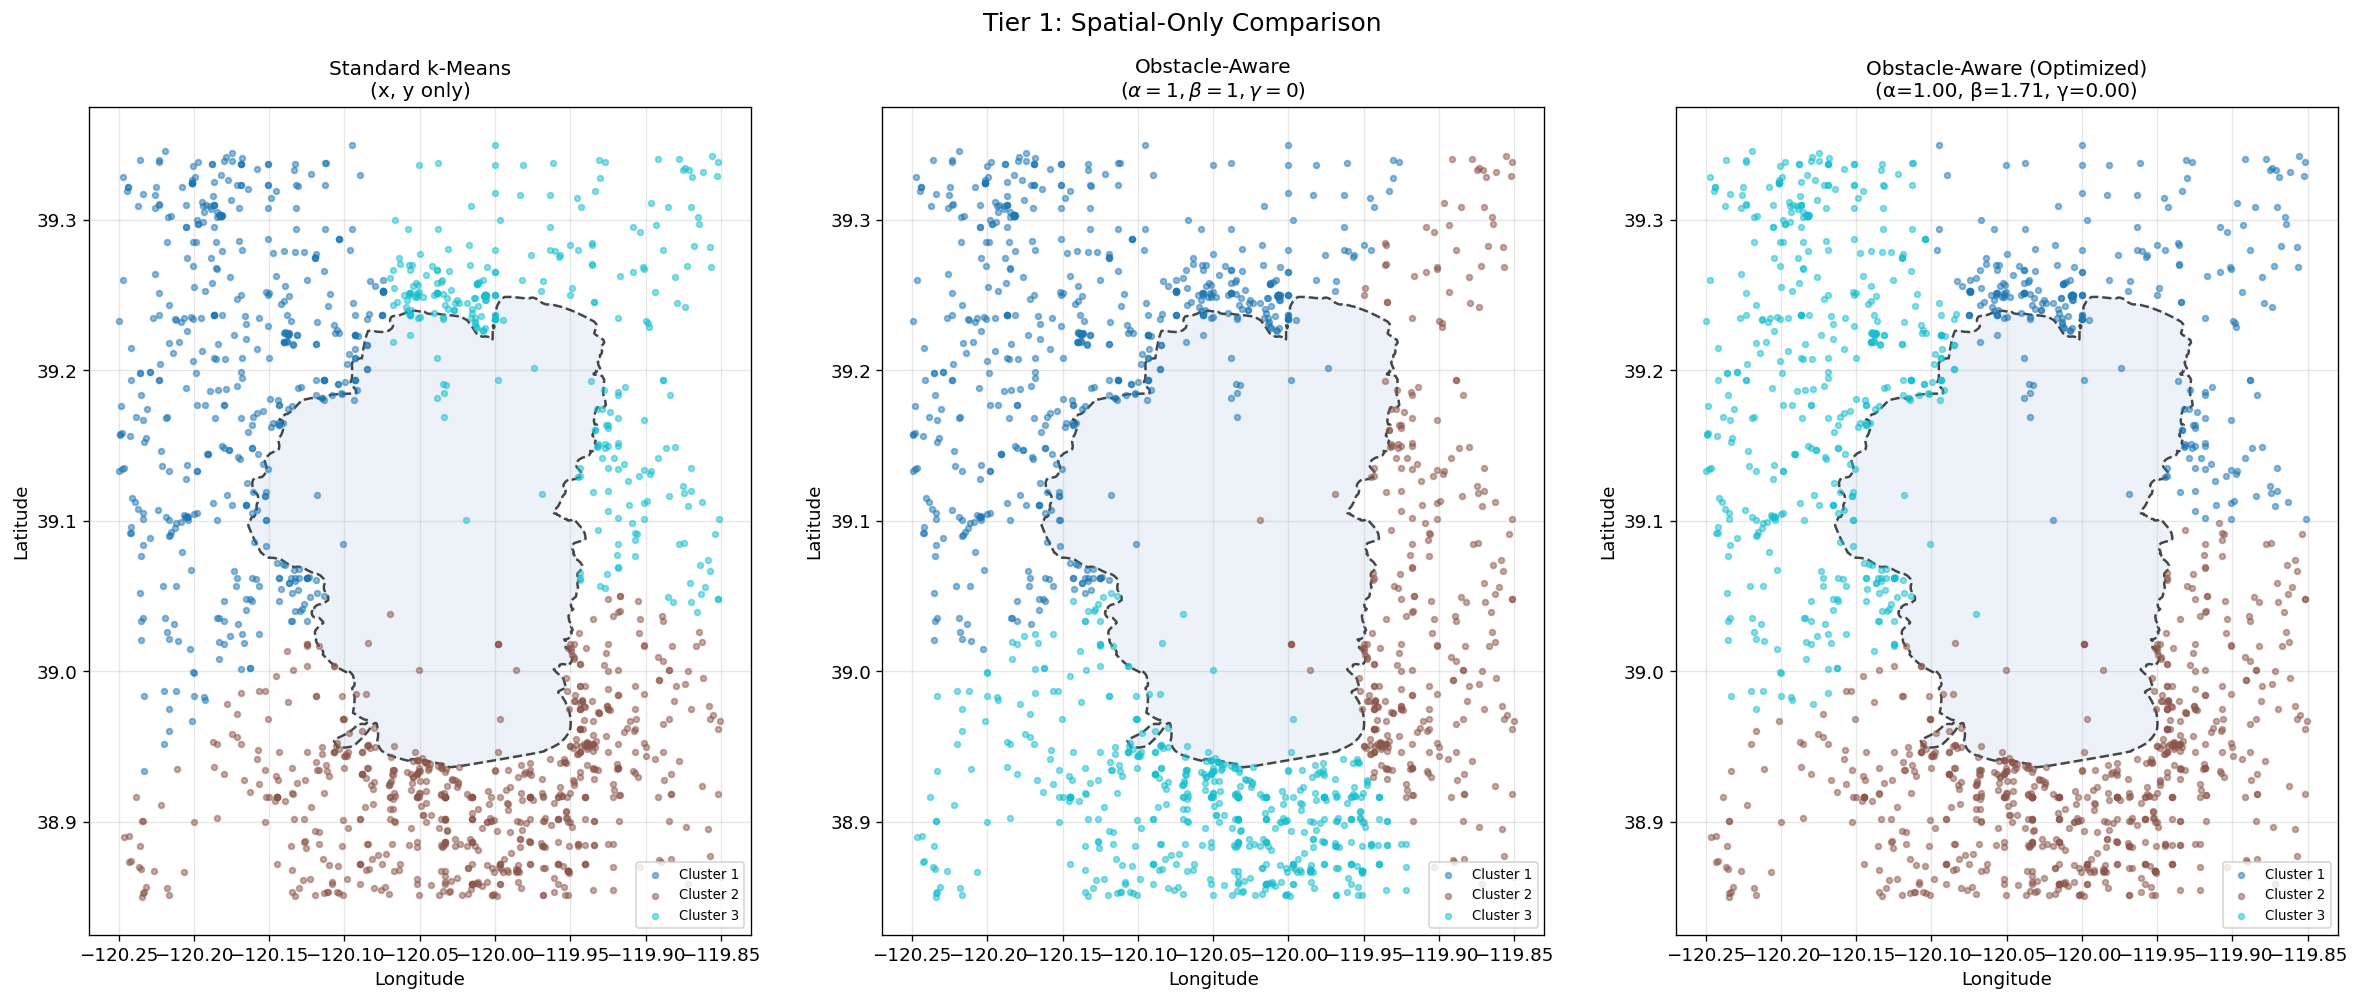

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

t1_titles = [
    'Standard k-Means\n(x, y only)',
    r'Obstacle-Aware' + '\n' + r'($\alpha=1, \beta=1, \gamma=0$)',
    f'Obstacle-Aware (Optimized)\n' + f'(\u03b1=1.00, \u03b2={opt_beta_t1:.2f}, \u03b3=0.00)'
]
t1_labels = [labels_standard, labels_t1_equal, labels_t1_opt]

for col, (labels, title) in enumerate(zip(t1_labels, t1_titles)):
    ax = axes[col]
    for i in range(k):
        mask = labels == i
        ax.scatter(fires['LONGITUDE'].values[mask], fires['LATITUDE'].values[mask],
                   c=[colors(i)], s=12, alpha=0.5, label=f'Cluster {i+1}', zorder=3)
    ax.plot(spline_pts[:, 0], spline_pts[:, 1], 'k--', linewidth=1.5, alpha=0.7)
    ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=8, loc='lower right')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('Tier 1: Spatial-Only Comparison', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 13. Tier 1: Summary

The Tier 1 results demonstrate the core contribution of the arc-length parameter:

- **Both obstacle-aware methods outperform standard k-Means** on mean arc-length span, confirming that the $s$ parameter helps produce clusters that better respect the lake boundary.
- **The obstacle-aware methods are directly comparable** via $\bar{\rho}$: the optimized version achieves the lowest distortion in the $(x, y, s)$ space, indicating tighter overall clustering. However, the arclength span is 0.01 worse in the optimized version than in the equal weights version. This is still small compared to the 0.05 gap between standard and obstacle-aware clustering.
- The improvement from equal weights to optimized weights is modest in Tier 1, suggesting that the arc-length parameter is already helpful at $\beta = 1$ and fine-tuning provides incremental gains.

The key takeaway: **including the arc-length parameter reduces the tendency for clusters to span across the lake**, producing zones that are more geographically coherent around the obstacle. This validates the approach introduced with synthetic data in Notebook 01, now confirmed on real wildfire data.

---

# TIER 2: Spatial + Attribute Comparison

**Goal**: Show that the framework extends to incorporate fire attributes (size and cause), creating clusters that are both spatially coherent and behaviorally distinct.

In Tier 2, the full distance metric is used:

$$d^2 = \alpha^2 \cdot \|\text{geo}\|^2 + \beta^2 \cdot d_s(s_i, s_j)^2 + \gamma^2 \cdot \|\text{attr}\|^2$$

The objective function $J = \bar{\rho} + (1 - \sigma_a)$ now includes attribute separation $\sigma_a$, which measures whether clusters differ significantly in fire size and cause type (using Kruskal-Wallis omnibus tests with Dunn's post-hoc pairwise comparisons and Bonferroni correction).

We compare:
1. **Standard k-Means** on $(x, y, \text{fire\_size}, \text{cause})$ — baseline with attributes but no arc-length
2. **Obstacle-aware** on $(x, y, s, \text{fire\_size}, \text{cause})$ with $\alpha = \beta = \gamma = 1$
3. **Obstacle-aware** with optimized $\beta$ and $\gamma$ ($\alpha = 1$ fixed)

**Design choice**: We constrain $\gamma \in [0, 1]$ (so $\gamma \leq \alpha$) to ensure that attributes *inform* the clustering without overriding the spatial structure. Without this constraint, the optimizer exploits the strong cause-type signal to maximize $\sigma_a$ at the expense of geographic coherence, producing clusters that aren't useful as spatial management zones.

## 14. Tier 2: Standard k-Means with Attributes

In [19]:
# Standard k-Means baseline for Tier 2: (x, y, fire_size, cause) — no s
X_std_attr = np.column_stack([
    xy_scaled,
    fire_size_scaled.ravel(),
    fires['cause_binary'].values
])

kmeans_t2_std = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_t2_std = kmeans_t2_std.fit_predict(X_std_attr)

print(f'Tier 2 standard k-Means (with attributes, no s):')
print(f'Cluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_t2_std == i)} fires')

sigma_t2_std, _ = attribute_separation(X, labels_t2_std, k, attr_indices=[3, 4])
print(f'\nAttribute separation (sigma_a): {sigma_t2_std:.4f}')

Tier 2 standard k-Means (with attributes, no s):
Cluster sizes:
  Cluster 1: 374 fires
  Cluster 2: 565 fires
  Cluster 3: 526 fires

Attribute separation (sigma_a): 0.3333


## 15. Tier 2: Obstacle-Aware with Attributes (Equal Weights)

We use the full feature vector $(x, y, s, \text{fire\_size}, \text{cause})$ with $\alpha = \beta = \gamma = 1$. This gives all three domains — geography, arc-length, and attributes — equal influence.

In [20]:
# Obstacle-aware k-Means: full features, equal weights
model_t2_equal = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=1.0, gamma=1.0,
    random_state=42, n_attr=2
)
model_t2_equal.fit(X, t_data=fires['t_param'].values)
labels_t2_equal = model_t2_equal.labels_

sigma_t2_eq, _ = attribute_separation(X, labels_t2_equal, k, attr_indices=[3, 4])

print(f'Tier 2 obstacle-aware (equal weights):')
print(f'rho_bar: {model_t2_equal.rho_bar_:.4f}')
print(f'sigma_a: {sigma_t2_eq:.4f}')
print(f'J = rho_bar + (1 - sigma_a): {model_t2_equal.rho_bar_ + (1 - sigma_t2_eq):.4f}')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_t2_equal == i)} fires')

Tier 2 obstacle-aware (equal weights):
rho_bar: 0.1405
sigma_a: 0.3333
J = rho_bar + (1 - sigma_a): 0.8072

Cluster sizes:
  Cluster 1: 522 fires
  Cluster 2: 374 fires
  Cluster 3: 569 fires


## 16. Tier 2: Optimizing $\beta$ and $\gamma$

With $\alpha = 1$ fixed, we search for the best $\beta \in [0, 2]$ and $\gamma \in [0, 1]$. This 2D optimization uses simulated annealing to minimize $J = \bar{\rho} + (1 - \sigma_a)$, balancing spatial tightness against attribute differentiation.

**Note**: This cell takes approximately 30-60 minutes with `maxiter=100`.

In [21]:
# 2D optimization: beta and gamma, alpha=1 fixed
def objective_t2(params):
    """Objective for Tier 2: optimize (beta, gamma)."""
    beta, gamma = params
    return objective_function(
        (alpha_fixed, beta, gamma),
        X, fires['t_param'].values, boundary,
        k=k, n_attr=2, attr_indices=[3, 4], random_state=42
    )

def progress_callback_t2(x, f, context):
    print(f'  beta={x[0]:.4f}, gamma={x[1]:.4f}, J={f:.4f}')

print('Tier 2: Optimizing beta and gamma (alpha=1.0 fixed)...')

sa_t2 = dual_annealing(
    objective_t2,
    bounds=[(0, 2), (0, 1)],
    seed=42,
    maxiter=100,
    callback=progress_callback_t2
)

opt_beta_t2 = sa_t2.x[0]
opt_gamma_t2 = sa_t2.x[1]

# Refit with optimal weights
model_t2_opt = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=alpha_fixed, beta=opt_beta_t2, gamma=opt_gamma_t2,
    random_state=42, n_attr=2
)
model_t2_opt.fit(X, t_data=fires['t_param'].values)
labels_t2_opt = model_t2_opt.labels_

sigma_t2_opt, _ = attribute_separation(X, labels_t2_opt, k, attr_indices=[3, 4])

print(f'\nOptimization complete!')
print(f'  alpha (fixed): {alpha_fixed:.4f}')
print(f'  Optimal beta:  {opt_beta_t2:.4f}')
print(f'  Optimal gamma: {opt_gamma_t2:.4f}')
print(f'  Objective J:   {sa_t2.fun:.4f}')
print(f'  rho_bar:       {model_t2_opt.rho_bar_:.4f}')
print(f'  sigma_a:       {sigma_t2_opt:.4f}')

Tier 2: Optimizing beta and gamma (alpha=1.0 fixed)...
  beta=0.1017, gamma=0.5090, J=0.7294
  beta=0.1669, gamma=0.3697, J=0.7291
  beta=0.8943, gamma=0.3749, J=0.7279
  beta=1.8638, gamma=0.3420, J=0.7271
  beta=1.7834, gamma=0.6426, J=0.6135
  beta=0.9644, gamma=0.5559, J=0.5713
  beta=1.2023, gamma=0.5559, J=0.5687
  beta=1.3741, gamma=0.6548, J=0.4486
  beta=1.1569, gamma=0.5725, J=0.4480
  beta=1.6631, gamma=0.6418, J=0.4443

Optimization complete!
  alpha (fixed): 1.0000
  Optimal beta:  1.6631
  Optimal gamma: 0.6418
  Objective J:   0.4443
  rho_bar:       0.1110
  sigma_a:       0.6667


## 17. Tier 2: Objective Surface

The 2D optimization landscape shows how the objective $J = \bar{\rho} + (1 - \sigma_a)$ varies with $\beta$ (arc-length weight) and $\gamma$ (attribute weight), with $\alpha = 1$ fixed.

**Note**: This cell takes approximately 30-60 minutes to compute.

Computing Tier 2 objective surface...
  20/144 (14%)
  40/144 (28%)
  60/144 (42%)
  80/144 (56%)
  100/144 (69%)
  120/144 (83%)
  140/144 (97%)


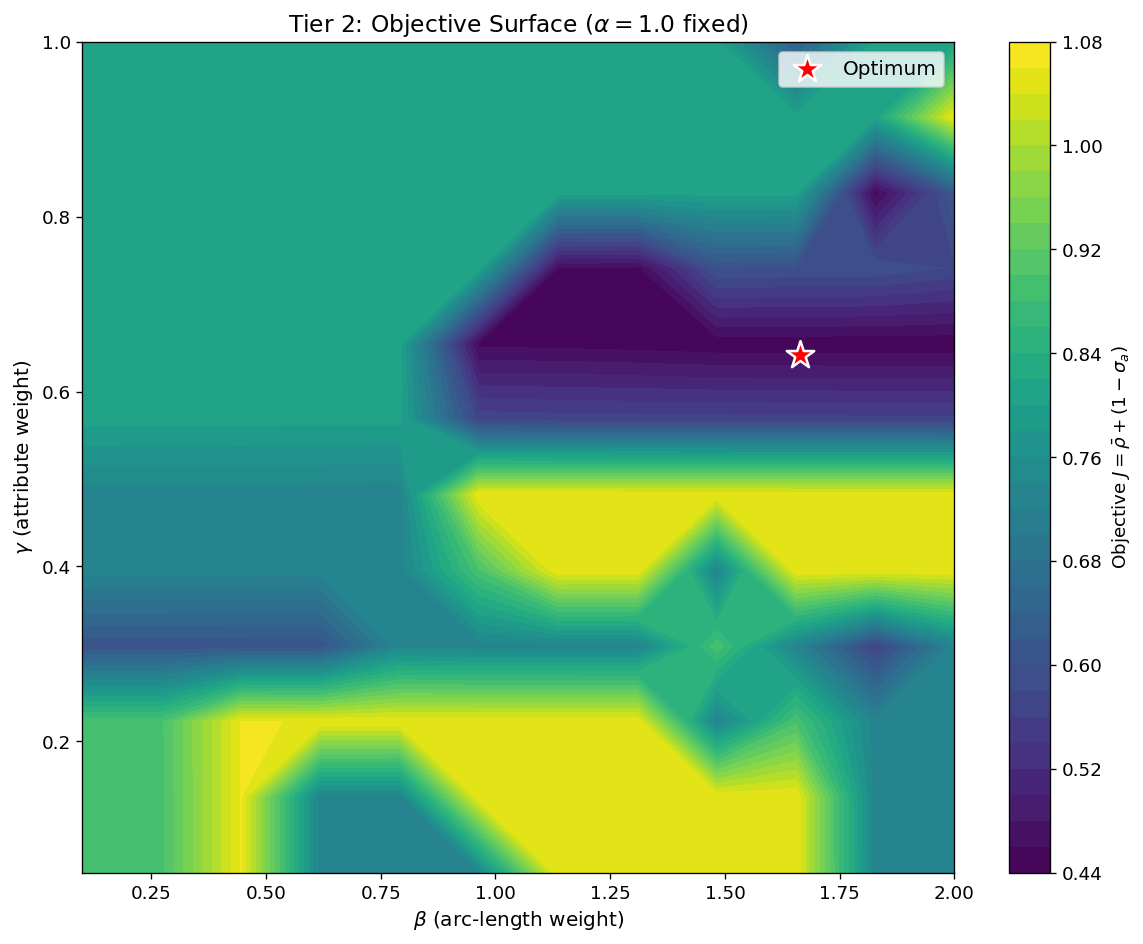

Surface computation complete.


In [22]:
# Compute objective surface over (beta, gamma)
print('Computing Tier 2 objective surface...')

beta_range = np.linspace(0.1, 2.0, 12)
gamma_range = np.linspace(0.05, 1.0, 12)
beta_grid, gamma_grid = np.meshgrid(beta_range, gamma_range)
obj_grid = np.zeros_like(beta_grid)

total = beta_grid.shape[0] * beta_grid.shape[1]
count = 0
for i in range(beta_grid.shape[0]):
    for j in range(beta_grid.shape[1]):
        obj_grid[i, j] = objective_function(
            (alpha_fixed, beta_grid[i, j], gamma_grid[i, j]),
            X, fires['t_param'].values, boundary,
            k=k, n_attr=2, attr_indices=[3, 4], random_state=42
        )
        count += 1
        if count % 20 == 0:
            print(f'  {count}/{total} ({100*count/total:.0f}%)')

fig, ax = plt.subplots(figsize=(10, 8))
contour = ax.contourf(beta_grid, gamma_grid, obj_grid, levels=30, cmap='viridis')
plt.colorbar(contour, ax=ax, label=r'Objective $J = \bar{\rho} + (1 - \sigma_a)$')
ax.scatter(opt_beta_t2, opt_gamma_t2, c='red', marker='*', s=300,
           edgecolors='white', linewidth=1.5, zorder=5, label='Optimum')
ax.set_xlabel(r'$\beta$ (arc-length weight)', fontsize=12)
ax.set_ylabel(r'$\gamma$ (attribute weight)', fontsize=12)
ax.set_title(r'Tier 2: Objective Surface ($\alpha = 1.0$ fixed)', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print('Surface computation complete.')

## 18. Tier 2: Cluster Profiles (Optimized)

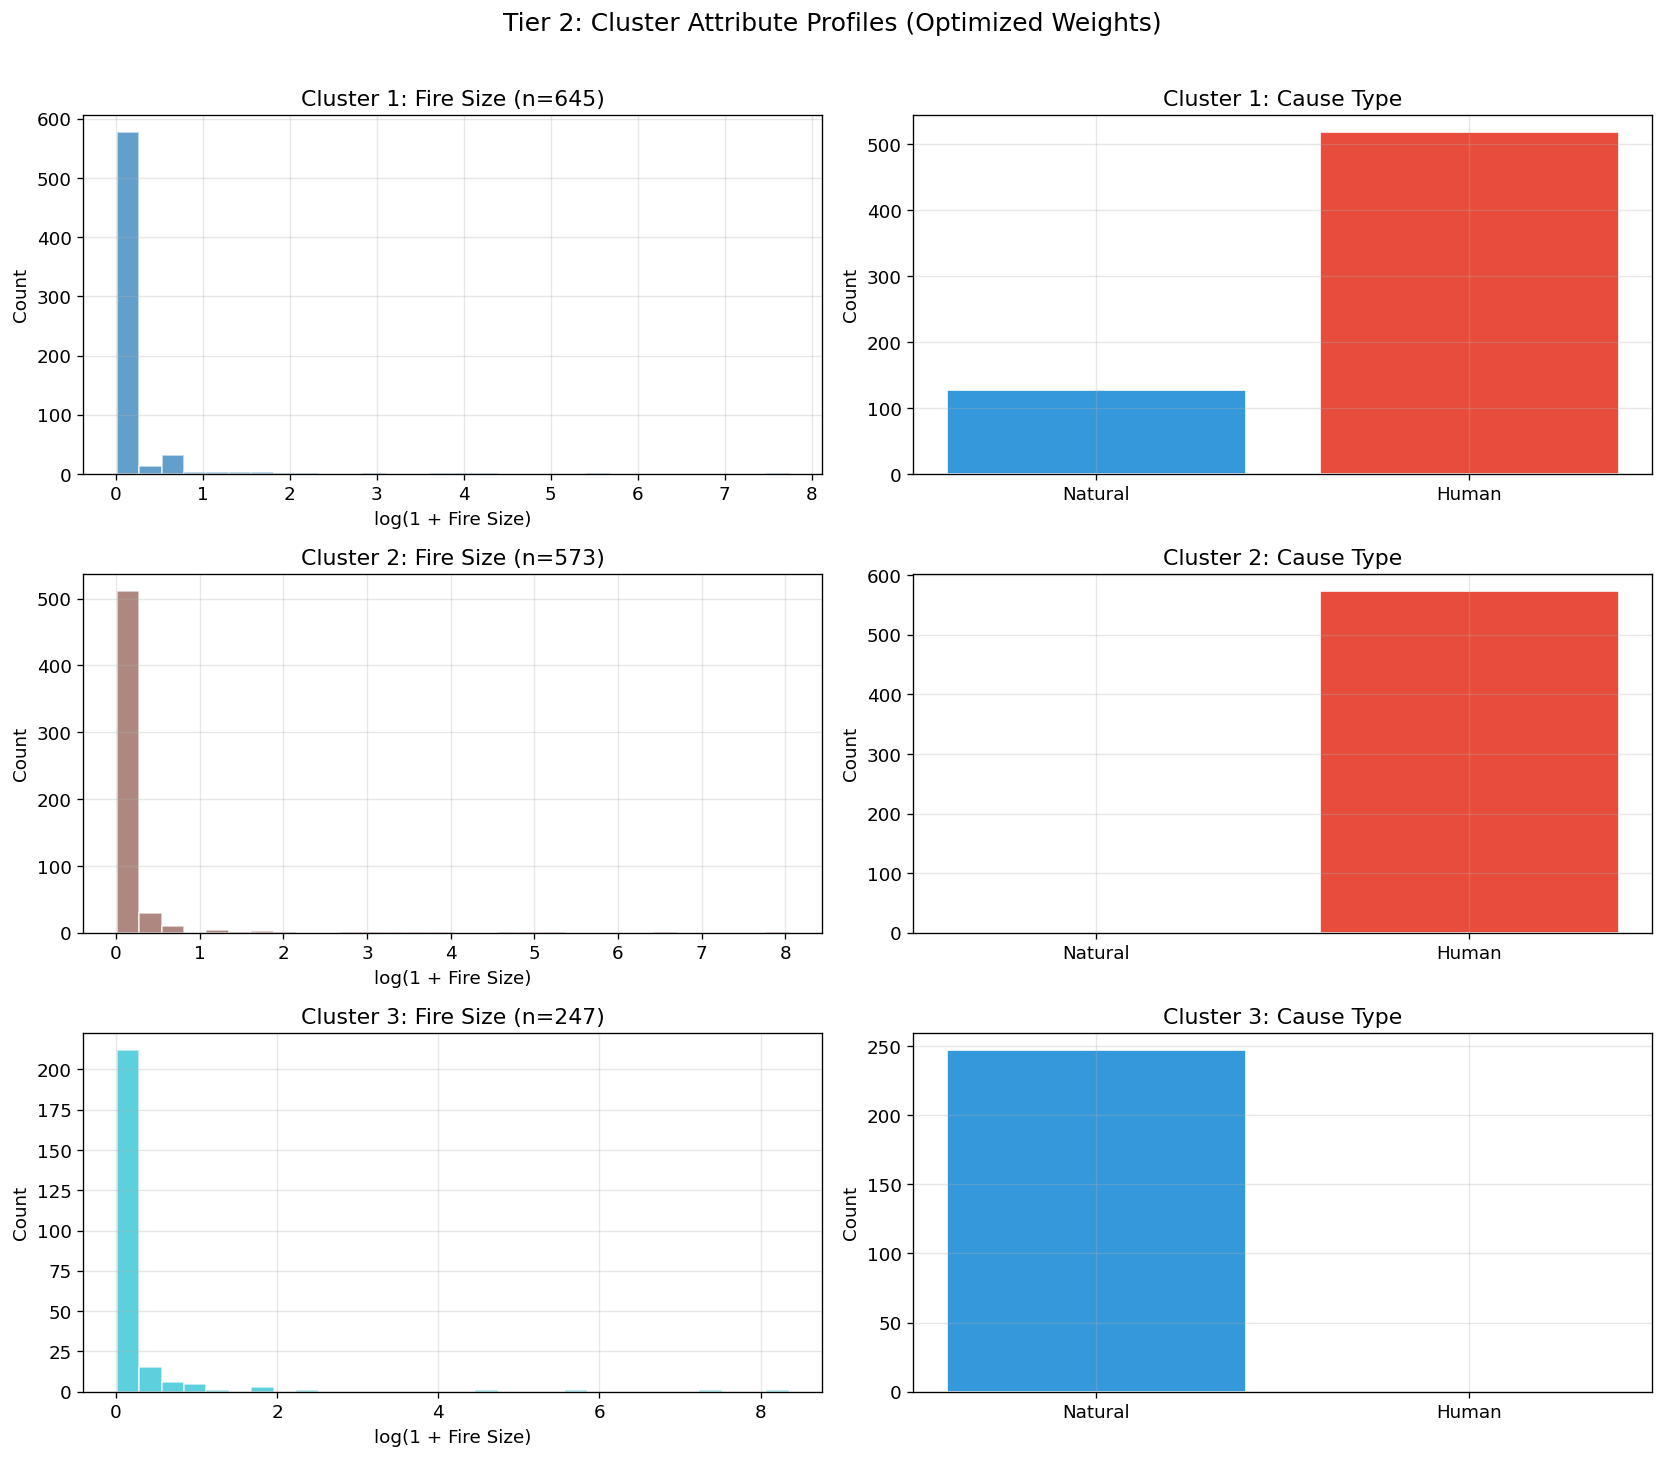

Tier 2 optimized cluster summary:
Cluster    Size     Mean Fire Size   % Natural    Mean s    
--------------------------------------------------------
1          645      4.49             19.7         0.268     
2          573      7.85             0.0          0.795     
3          247      25.72            100.0        0.682     


In [23]:
fires['cluster_t2_opt'] = labels_t2_opt

fig, axes = plt.subplots(k, 2, figsize=(14, 4 * k))

for i in range(k):
    cluster = fires[fires['cluster_t2_opt'] == i]

    ax = axes[i, 0]
    ax.hist(cluster['fire_size_log'], bins=30, color=colors(i),
            edgecolor='white', alpha=0.7)
    ax.set_xlabel('log(1 + Fire Size)')
    ax.set_ylabel('Count')
    ax.set_title(f'Cluster {i+1}: Fire Size (n={len(cluster)})')
    ax.grid(True, alpha=0.3)

    ax = axes[i, 1]
    cause_counts = cluster['cause_binary'].value_counts().sort_index()
    labels_cause = ['Natural', 'Human']
    bar_colors = ['#3498db', '#e74c3c']
    bars = ax.bar(labels_cause, [cause_counts.get(0, 0), cause_counts.get(1, 0)],
                  color=bar_colors, edgecolor='white')
    ax.set_ylabel('Count')
    ax.set_title(f'Cluster {i+1}: Cause Type')
    ax.grid(True, alpha=0.3)

plt.suptitle('Tier 2: Cluster Attribute Profiles (Optimized Weights)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print('Tier 2 optimized cluster summary:')
print(f'{"Cluster":<10} {"Size":<8} {"Mean Fire Size":<16} {"% Natural":<12} {"Mean s":<10}')
print('-' * 56)
for i in range(k):
    cluster = fires[fires['cluster_t2_opt'] == i]
    print(f'{i+1:<10} {len(cluster):<8} '
          f'{cluster["FIRE_SIZE"].mean():<16.2f} '
          f'{(cluster["cause_binary"] == 0).mean() * 100:<12.1f} '
          f'{cluster["s_param"].mean():<10.3f}')

## 19. Tier 2: Visual Comparison

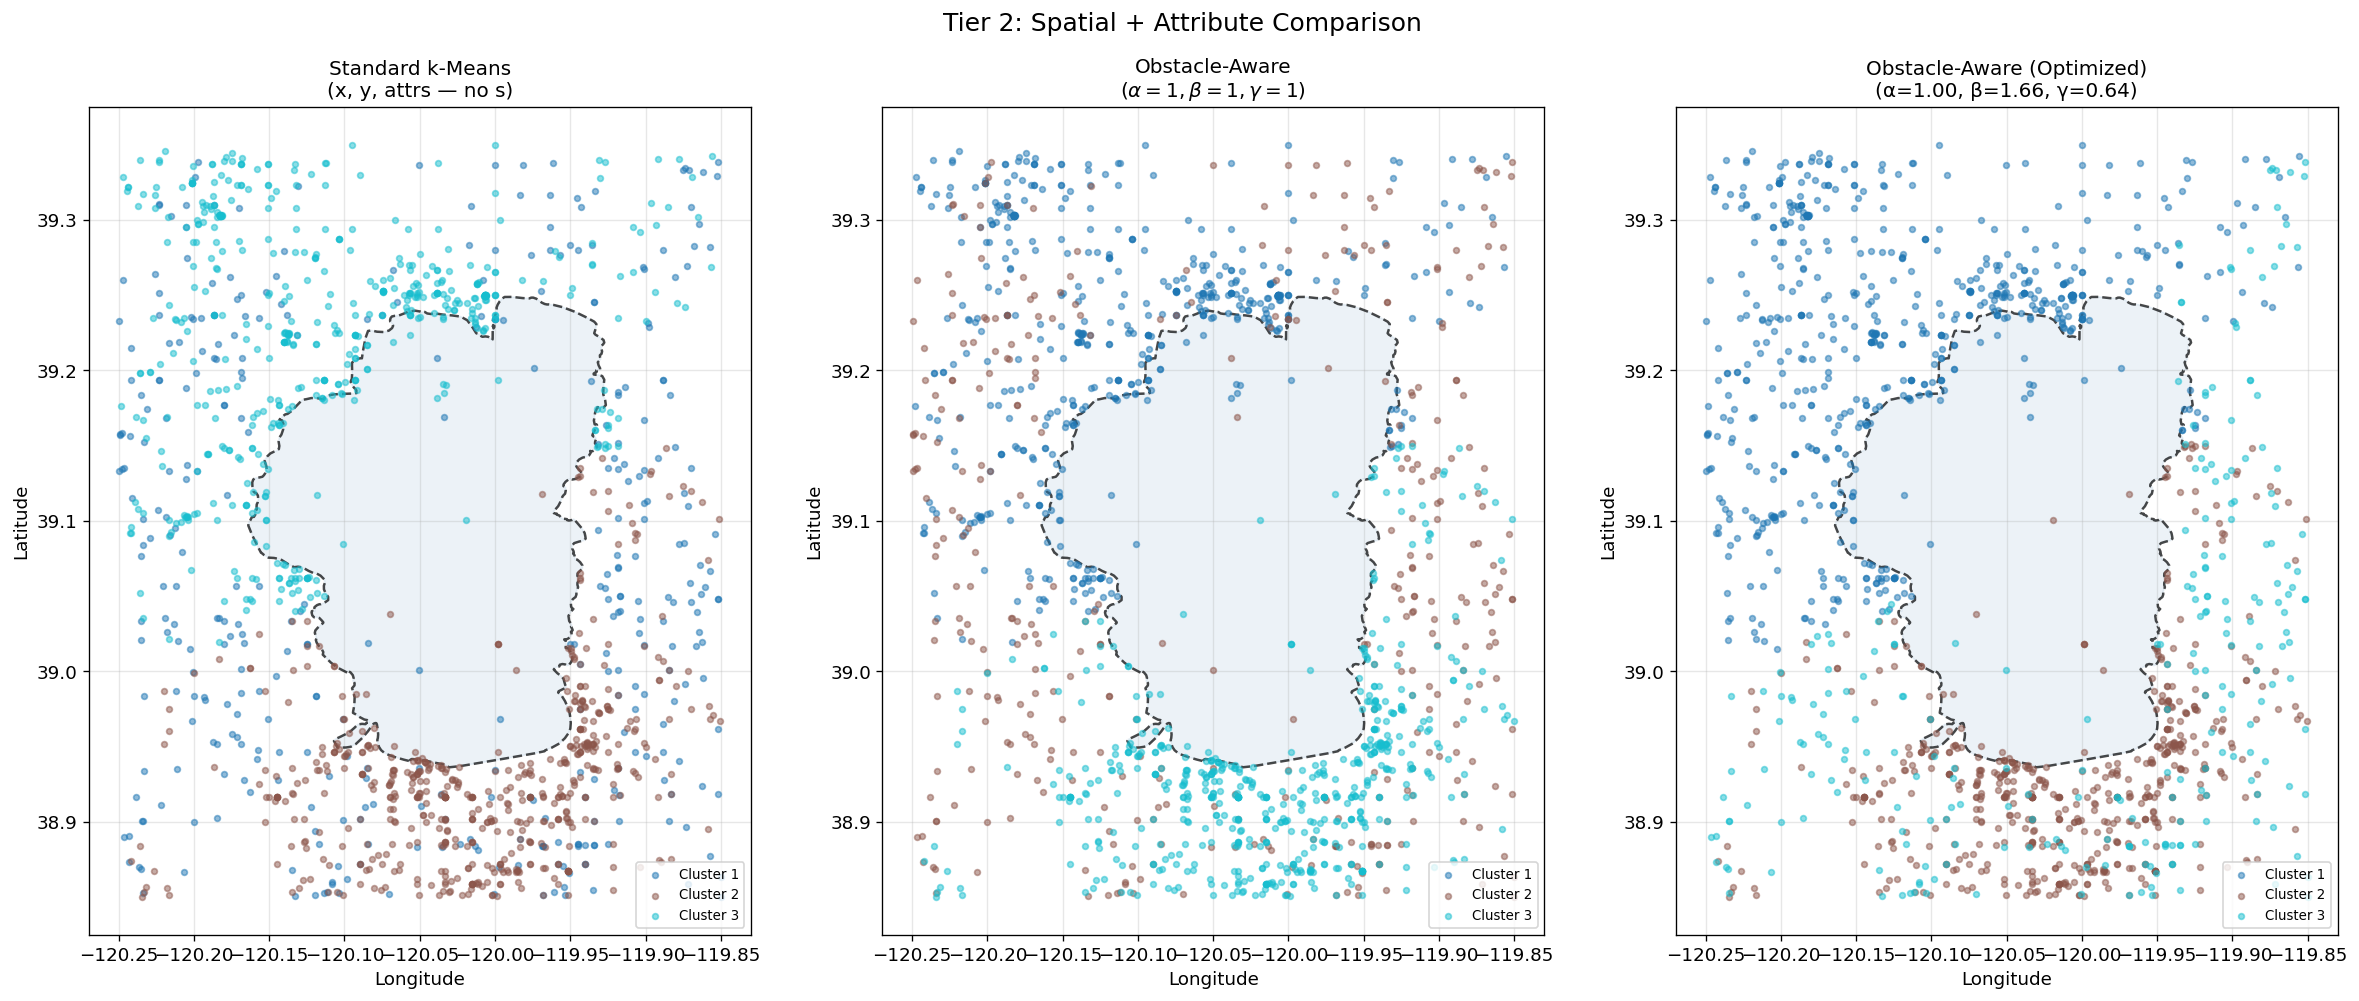

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

t2_titles = [
    'Standard k-Means\n(x, y, attrs — no s)',
    r'Obstacle-Aware' + '\n' + r'($\alpha=1, \beta=1, \gamma=1$)',
    f'Obstacle-Aware (Optimized)\n'
    f'(\u03b1=1.00, \u03b2={opt_beta_t2:.2f}, \u03b3={opt_gamma_t2:.2f})'
]
t2_labels = [labels_t2_std, labels_t2_equal, labels_t2_opt]

for col, (labels, title) in enumerate(zip(t2_labels, t2_titles)):
    ax = axes[col]
    for i in range(k):
        mask = labels == i
        ax.scatter(fires['LONGITUDE'].values[mask], fires['LATITUDE'].values[mask],
                   c=[colors(i)], s=12, alpha=0.5, label=f'Cluster {i+1}', zorder=3)
    ax.plot(spline_pts[:, 0], spline_pts[:, 1], 'k--', linewidth=1.5, alpha=0.7)
    ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=8, loc='lower right')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('Tier 2: Spatial + Attribute Comparison', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 20. Tier 2: Quantitative Comparison

In Tier 2, we have two comparable metrics:
- **$\sigma_a$ (attribute separation)**: Computed identically for all methods — it evaluates whether cluster labels produce groups with statistically distinct fire size and cause profiles.
- **Arc-length span**: Same metric from Tier 1 — measures spatial coherence around the lake.

A successful dual-domain clustering achieves *both* high $\sigma_a$ (distinct fire behavior profiles) *and* low arc-length span (spatially contiguous zones).

In [25]:
# # Tier 2 quantitative comparison
# t2_methods = {
#     'Std k-Means (x,y,attrs)': labels_t2_std,
#     'Obstacle-Aware (equal)': labels_t2_equal,
#     f'Obstacle-Aware (optimized)': labels_t2_opt,
# }

# sigma_t2_std_val, _ = attribute_separation(X, labels_t2_std, k, attr_indices=[3, 4])
# sigma_t2_eq_val, _ = attribute_separation(X, labels_t2_equal, k, attr_indices=[3, 4])
# sigma_t2_opt_val, _ = attribute_separation(X, labels_t2_opt, k, attr_indices=[3, 4])

# print('TIER 2 QUANTITATIVE COMPARISON')
# print('=' * 65)
# print(f'\n{"Method":<35} {"sigma_a":>10} {"Mean Arc Span":>15}')
# print('-' * 62)

# for (name, labels), sigma in zip(t2_methods.items(),
#                                    [sigma_t2_std_val, sigma_t2_eq_val, sigma_t2_opt_val]):
#     spans = [arc_length_span(fires['s_param'].values[labels == i]) for i in range(k)]
#     mean_span = np.mean(spans)
#     print(f'{name:<35} {sigma:>10.4f} {mean_span:>15.3f}')

# Tier 2 quantitative comparison
t2_methods = {
    'Std k-Means (x,y,attrs)': labels_t2_std,
    'Obstacle-Aware (equal)': labels_t2_equal,
    f'Obstacle-Aware (optimized)': labels_t2_opt,
}

sigma_t2_std_val, _ = attribute_separation(X, labels_t2_std, k, attr_indices=[3, 4])
sigma_t2_eq_val, _ = attribute_separation(X, labels_t2_equal, k, attr_indices=[3, 4])
sigma_t2_opt_val, _ = attribute_separation(X, labels_t2_opt, k, attr_indices=[3, 4])

print('TIER 2 QUANTITATIVE COMPARISON')
print('=' * 80)
print(f'\n{"Method":<35} {"sigma_a":>10} {"Cl 1":>8} {"Cl 2":>8} {"Cl 3":>8} {"Mean":>8}')
print('-' * 75)

for (name, labels), sigma in zip(t2_methods.items(),
                                   [sigma_t2_std_val, sigma_t2_eq_val, sigma_t2_opt_val]):
    spans = [arc_length_span(fires['s_param'].values[labels == i]) for i in range(k)]
    mean_span = np.mean(spans)
    print(f'{name:<35} {sigma:>10.4f} {spans[0]:>8.3f} {spans[1]:>8.3f} {spans[2]:>8.3f} {mean_span:>8.3f}')

print(f'\n  Arc span columns show per-cluster values (lower = more coherent).')


TIER 2 QUANTITATIVE COMPARISON

Method                                 sigma_a     Cl 1     Cl 2     Cl 3     Mean
---------------------------------------------------------------------------
Std k-Means (x,y,attrs)                 0.3333    0.930    0.510    0.577    0.672
Obstacle-Aware (equal)                  0.3333    0.522    0.930    0.510    0.654
Obstacle-Aware (optimized)              0.6667    0.493    0.511    0.603    0.536

  Arc span columns show per-cluster values (lower = more coherent).


## 21. Saving Results

We save the clustered fire data with labels from both tiers for use in Notebook 04 (interactive maps and final visualizations).

In [26]:
# Save clustered fire data
fires['cluster_t1_equal'] = labels_t1_equal
fires['cluster_t1_opt'] = labels_t1_opt
fires['cluster_t2_std'] = labels_t2_std
fires['cluster_t2_equal'] = labels_t2_equal
fires['cluster_t2_opt'] = labels_t2_opt

output_cols = ['LATITUDE', 'LONGITUDE', 'FIRE_SIZE', 'NWCG_GENERAL_CAUSE',
               'cause_binary', 'FIRE_YEAR', 'DISCOVERY_DOY',
               't_param', 's_param', 'fire_size_log',
               'cluster_t1_equal', 'cluster_t1_opt',
               'cluster_t2_std', 'cluster_t2_equal', 'cluster_t2_opt']
fires[output_cols].to_csv('../data/processed/tahoe_fires_clustered.csv', index=False)

# Save optimal parameters
import json as json_lib
opt_params = {
    'tier1': {
        'alpha': alpha_fixed,
        'beta': opt_beta_t1,
        'gamma': 0.0,
        'rho_bar': model_t1_opt.rho_bar_,
    },
    'tier2': {
        'alpha': alpha_fixed,
        'beta': opt_beta_t2,
        'gamma': opt_gamma_t2,
        'objective': sa_t2.fun,
        'rho_bar': model_t2_opt.rho_bar_,
        'sigma_a': sigma_t2_opt,
    },
    'k': k,
    'n_fires': len(fires),
}
with open('../data/processed/optimal_params.json', 'w') as f:
    json_lib.dump(opt_params, f, indent=2)

print(f'Saved {len(fires)} clustered fires to data/processed/tahoe_fires_clustered.csv')
print(f'Saved optimal parameters to data/processed/optimal_params.json')

Saved 1465 clustered fires to data/processed/tahoe_fires_clustered.csv
Saved optimal parameters to data/processed/optimal_params.json


## 22. Discussion

### Tier 1: The Arc-Length Parameter Works

The spatial-only comparison isolates the core contribution of this project. Standard k-Means treats Lake Tahoe as if it doesn't exist, assigning fires purely by Euclidean proximity. The obstacle-aware algorithm incorporates each fire's position along the shoreline via the arc-length parameter $s$, producing clusters that respect the lake as a geographic barrier.

Both obstacle-aware methods reduced the mean arc-length span compared to standard k-Means (0.329 and 0.339 vs. 0.381), confirming that the $s$ parameter produces more spatially contiguous zones. The improvement from equal weights ($\beta = 1$) to optimized weights ($\beta \approx 1.7$) was modest, suggesting that the arc-length parameter is already effective at equal weighting and fine-tuning provides incremental gains.

The optimized $\beta > 1$ indicates that, at the optimal solution, arc-length position is weighted more heavily than raw geographic distance. This makes sense for the Lake Tahoe geometry: fires that are geographically close but separated by the lake should be in different zones, and a higher $\beta$ enforces this separation.

### Tier 2: Dual-Domain Clustering

Adding fire attributes (size and cause) enables the algorithm to find clusters that are both spatially coherent and behaviorally distinct. The optimized obstacle-aware method achieved the best performance on both metrics simultaneously: the highest attribute separation ($\sigma_a = 0.667$, compared to 0.333 for both baselines) and the lowest arc-length span (0.536, compared to 0.672 for standard k-Means with attributes).

The optimized clusters have interpretable management profiles:
- A **natural fire zone** (100% lightning-caused, largest mean fire size) on the eastern/backcountry side of the lake
- A **human-caused zone** (entirely human-caused) concentrated around the south shore and southeast — the most developed and recreationally active area
- A **mixed zone** (predominantly human-caused with some natural fires) on the west and north shore

The constraint $\gamma \leq 1$ (ensuring attributes don't overpower geography) was essential. Without it, the optimizer exploited the strong binary cause signal to achieve near-perfect attribute separation but at the cost of geographic coherence — producing clusters that were statistically optimal but not useful as spatial management zones.

### Methodological Notes

- **Weight normalization**: We fix $\alpha = 1$ without loss of generality, since only the ratios between weights affect cluster assignments.
- **Boundary choice**: We use the lake shoreline as the obstacle boundary because it defines the fundamental geographic barrier. The road network approximately follows the shoreline and would produce a similar arc-length ordering (see Notebook 02).
- **Fire size transformation**: We use $\log(1 + \text{fire size})$ because fire sizes span several orders of magnitude (0.01 to 4,222 acres). The log transformation prevents rare large fires from dominating the distance metric.
- **Cause encoding**: The binary Natural/Human classification simplifies the NWCG cause categories into a single feature capturing the primary management distinction.
- **Stochastic sensitivity**: The objective surface for Tier 2 is bumpy due to the stochastic nature of k-Means initialization. The optimal weights should be interpreted as approximate — nearby weight values produce comparable results.

### Key Files Produced

| File | Description |
|------|-------------|
| `data/processed/tahoe_fires_clustered.csv` | Fire records with cluster labels from all comparisons |
| `data/processed/optimal_params.json` | Optimal weights and performance metrics for both tiers |